In [1]:
import pandas as pd

In [2]:
import torch
from torch import nn, optim

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [5]:
import random

In [6]:
import numpy as np

In [45]:
import matplotlib.pyplot as plot

In [7]:
df = pd.read_csv("C:/git/dados/nlp/news_sentiment_analysis.csv", encoding="utf-8")

In [9]:
df = df[["Description", "Type"]]

In [10]:
df

,Description,Type
0,"ST. GEORGE — Kaitlyn Larson, a first-year teac...",Business
1,"Harare, Zimbabwe – Local businesses are grappl...",Business
2,(marketscreener.com) Billionaire Elon Musk has...,Business
3,(marketscreener.com) A U.S. trade regulator on...,Business
4,4.5 million households in the U.S. have solar ...,Business
...,...,...
3495,QRG Capital Management Inc. increased its stak...,Technology
3496,QRG Capital Management Inc. bought a new posit...,Technology
3497,QRG Capital Management Inc. boosted its stake ...,Technology
3498,"WESTFORD, Mass., July 18, 2024 /PRNewswire/ --...",Technology


In [141]:
df["Type"].unique()

array(['Business', 'Entertainment', 'General', 'Health', 'Science',
       'Sports', 'Technology'], dtype=object)

In [143]:
# mapping_type = {
#         'Business': [1, 0, 0, 0, 0, 0, 0], 
#         'Entertainment': [0, 1, 0, 0, 0, 0, 0], 
#         'General': [0, 0, 1, 0, 0, 0, 0], 
#         'Health': [0, 0, 0, 1, 0, 0, 0], 
#         'Science': [0, 0, 0, 0, 1, 0, 0], 
#         'Sports': [0, 0, 0, 0, 0, 1, 0], 
#         'Technology': [0, 0, 0, 0, 0, 0, 1]
# } 
# df["type_number"] = df["Type"].map( mapping_type )

In [19]:
encoder = LabelEncoder()
oh_encoder = OneHotEncoder(sparse_output=False)

In [21]:
Y_label = encoder.fit_transform(df["Type"])
Y_label = Y_label.reshape(-1, 1)

In [23]:
Y = oh_encoder.fit_transform(Y_label)
oh_encoder.categories_

[array([0, 1, 2, 3, 4, 5, 6])]

In [ ]:
#         'Business': [1, 0, 0, 0, 0, 0, 0], 
#         'Entertainment': [0, 1, 0, 0, 0, 0, 0], 
#         'General': [0, 0, 1, 0, 0, 0, 0], 
#         'Health': [0, 0, 0, 1, 0, 0, 0], 
#         'Science': [0, 0, 0, 0, 1, 0, 0], 
#         'Sports': [0, 0, 0, 0, 0, 1, 0], 
#         'Technology': [0, 0, 0, 0, 0, 0, 1]

In [25]:
# Y = torch.tensor(df["type_number"], dtype=torch.float32)
# Y = torch.reshape( Y, (-1, 1) )
# Y.shape
Y = torch.tensor(Y, dtype=torch.float32)
Y

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [27]:
vetorizador = CountVectorizer(max_features = 1000)

In [29]:
X = vetorizador.fit_transform( df["Description"] )
X = torch.tensor(X.toarray(), dtype=torch.float32)
X

tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.]])

In [ ]:
vocabulario = vetorizador.get_feature_names_out()
vocabulario

In [39]:
modelo = nn.Linear(in_features = 1000, out_features = 7)
otimizador = optim.SGD( modelo.parameters(), lr=1)
criterio = nn.CrossEntropyLoss() # Cross Entropy Perda

In [41]:
lista_loss = []
for epoca in range(2000):
    y_hat = modelo( X ) 
    loss = criterio( y_hat, Y )
    lista_loss.append( loss )
    if epoca % 100 == 0:
        print(f"Loss: {loss}")
    otimizador.zero_grad()
    loss.backward()
    otimizador.step()

Loss: 1.9507887363433838
Loss: 0.32847440242767334
Loss: 0.23412193357944489
Loss: 0.1923130303621292
Loss: 0.1674351692199707
Loss: 0.1503629982471466
Loss: 0.13770116865634918
Loss: 0.12787528336048126
Loss: 0.12003476172685623
Loss: 0.11363444477319717
Loss: 0.10830146819353104
Loss: 0.10378199070692062
Loss: 0.09989781677722931
Loss: 0.096519835293293
Loss: 0.0935523733496666
Loss: 0.09092345088720322
Loss: 0.08857786655426025
Loss: 0.08647259324789047
Loss: 0.08457325398921967
Loss: 0.08285178989171982


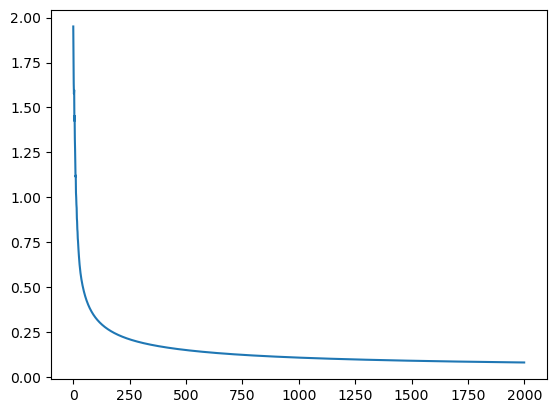

In [57]:
lista_tensor = torch.tensor( lista_loss ) 
plot.plot( lista_tensor )

In [233]:
posicao = random.randint(0, 3499)
tipo_correto = df["Type"][posicao]
texto = df["Description"][posicao]
print(posicao, ":", tipo_correto, "<->", texto)
# texto =  "trade war occurs in all world, causing faminy and disgrace" # df["Description"][900]
# resultado = df["sentiment_number"][900]
# print(f"Resultado: {resultado}\t\tDescricao: {texto}")

518 : Sports <-> Golden State Warriors coach Steve Kerr raised some eyebrows this week with a remark he made about what sort of players the team might be willing to give up in offseason trades. In an appearance on 95.7 The Game&#8217;s &#8220;Willard & Dibs,&#8221; Kerr was asked about rumors suggesting the Warriors could trade Jonathan Kuminga as...The post Steve Kerr raises eyebrows with comment about possible trades appeared first on Larry Brown Sports.


In [235]:
vetorizador_teste = CountVectorizer( vocabulary = vocabulario )
X_teste = vetorizador_teste.fit_transform( [texto] )
X_teste = torch.tensor( [X_teste.toarray()], dtype=torch.float32 )
X_teste.shape

torch.Size([1, 1, 1000])

In [237]:
Y_hat_teste = modelo( X_teste )
resultado = Y_hat_teste.detach().numpy()
indice = np.argmax(resultado)
encoder.inverse_transform( [indice] )

array(['Sports'], dtype=object)